In [23]:
import torch.nn as nn
import torch
# initialize and define base NN model
class MLP(nn.Module):
    def __init__(self, l1_param, l2_param=10):
        # define layers as attributes of the self object instance
        super().__init__()
        l1 = nn.Linear(l1_param,l2_param)
        a1 = nn.ReLU()
        l2 = nn.Linear(l2_param, 1)
        s1 = nn.Sigmoid()
        l = [l1, a1, l2, s1]
        
        # put all defined layers in nn.ModuleList object
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        # specify how layers are used in the forward pass of NN
        for f in self.module_list:
            x = f(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)
        return (pred >= 0.5).float() # return predicted class label 0/1 for the sample

    def weight_initialization(self):
        for layer in self.module_list:
            if isinstance(layer, nn.Linear):
                torch.nn.init.xavier_normal_(layer.weight)
        

In [24]:
from sklearn.model_selection import train_test_split
from torch.utils.data import (DataLoader, Dataset, TensorDataset)
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler,RobustScaler

class HeartDiseaseDataset(Dataset):
    def __init__(self, X, y):
        # split the data set into train, test and validate
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

        # Standardize X_train data
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # convert to tensors
        X_train = torch.from_numpy(X_train).to(torch.float32)
        y_train = torch.from_numpy(y_train.values).to(torch.float32)
        X_test = torch.from_numpy(X_test).to(torch.float32)
        y_test = torch.from_numpy(y_test.values).to(torch.float32)
        
        # set attributes
        self.X = X_train
        self.y = y_train

        self.X_test = X_test
        self.y_test = y_test

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)

In [25]:
from ray import tune

# define parameter configurations
config = {
    "lr": tune.loguniform(1e-4, 1e-3),
    'beta1': 0.9,
    'beta2': 0.999,
    'epsilon': 1e-8
}

In [34]:
import os
import ray 
import multiprocessing
import sys
import tempfile

# 2. CAPTURE YOUR CURRENT ABSOLUTE PROJECT PATH
# This ensures that no matter where Ray jumps, this string points to your folder
PROJECT_DIR = os.path.abspath(os.getcwd())

import torch.optim as optim
from ray.tune import Checkpoint
import pandas as pd
import numpy as np

def train(config):
    # load heart dataset
    csv_path = os.path.join(PROJECT_DIR+"/heart.csv")
    df = pd.read_csv(csv_path)

    # split into X and y columns
    idx = len(df.columns) - 1
    X = df.iloc[:, :idx]
    y = df.loc[:, 'target']

    # define number of epochs
    num_epochs = 200

    # initialize training and testing dataset
    train_ds = HeartDiseaseDataset(X, y)

    # define batch size
    batch_size = 10
    
    # set batchsize one for pytorch dataloader
    train_dl = DataLoader(train_ds, batch_size, shuffle=True, drop_last=False)
    
    # initialize model
    model = MLP(l1_param=13)

    # configure the first layer by specifying initial value for weight distribution
    model.weight_initialization()

    # define the loss function as MSE
    loss_fn = nn.BCELoss()

    optimizer = optim.Adam(model.parameters(), lr=config['lr'], betas=(config['beta1'], config['beta2']), eps=config['epsilon'])
    
    # initialize arrays to track training history
    loss_hist = [0] * num_epochs
    accuracy_hist = [0] * num_epochs
    
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            # forward prop step
            pred = model(x_batch)[:,0]
            # calculate the mean-squared loss
            loss = loss_fn(pred, y_batch)
            # backprop to calculate gradients
            loss.backward()
            # take a step in the negative direction of the gradient towards the supposed minima
            optimizer.step()
            # reset gradient to 0 for next batch
            optimizer.zero_grad() 

            # update current loss and accuracy metric tally
            loss_hist[epoch] += loss.item()
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist[epoch] += is_correct.mean()

        loss_hist[epoch] /= train_ds.__len__()/batch_size
        accuracy_hist[epoch] /= train_ds.__len__()/batch_size

        
        with tempfile.TemporaryDirectory() as checkpoint_dir:
            checkpoint = None
            if (epoch + 1) % 5 == 0:
                # save the model to its dedicated dir per checkpoint
                torch.save(
                    model.state_dict(),
                    os.path.join(checkpoint_dir, "model.pth")
                )
                checkpoint = Checkpoint.from_directory(checkpoint_dir)

            # Send the current training result back to Tune
            tune.report({"binary_cross_entropy_loss": loss_hist[epoch], "training_acc": accuracy_hist[epoch].numpy()}, checkpoint=checkpoint)
               

In [35]:
import matplotlib.pyplot as plt

checkpoint_absolute_path = os.path.abspath('./')

search_space = {
    "lr": tune.loguniform(1e-3, 5e-3),
    'beta1': tune.loguniform(0.8,0.9),
    'beta2': tune.loguniform(0.95,0.999),
    'epsilon': tune.loguniform(1e-8,1e-6)
}

tuner = tune.Tuner(
    train,
    run_config=ray.tune.RunConfig(storage_path=checkpoint_absolute_path,name='model_params'),
    param_space=search_space
)
results = tuner.fit()

2026-09-27 18:09:27,146	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/fatimasaadatali/heart_disease_mlp/HeartDiseaseMLP/model_params' in 0.0031s.
2026-09-27 18:09:27,148	INFO tune.py:1039 -- Total run time: 7.26 seconds (7.24 seconds for the tuning loop).


In [36]:
result_df = results.get_dataframe()
print(f'BCE Loss: {result_df.loc[0, 'binary_cross_entropy_loss']: .4f}')
print(f'Training Accuracy: {result_df.loc[0, 'training_acc']*100: .4f}%')
print(result_df.columns)

BCE Loss:  0.0413
Training Accuracy:  100.0000%
Index(['binary_cross_entropy_loss', 'training_acc', 'timestamp',
       'checkpoint_dir_name', 'done', 'training_iteration', 'trial_id', 'date',
       'time_this_iter_s', 'time_total_s', 'pid', 'hostname', 'node_ip',
       'time_since_restore', 'iterations_since_restore', 'config/lr',
       'config/beta1', 'config/beta2', 'config/epsilon', 'should_checkpoint',
       'logdir'],
      dtype='object')


In [37]:
# load progress_csv
file_path = results.get_best_result().checkpoint.path
progress_csv_path = ""

for string in file_path.split('/'):
    if not (string.startswith('checkpoint')):
        progress_csv_path += string + '/'

data = pd.read_csv(progress_csv_path + 'progress.csv')

bce_loss = data['binary_cross_entropy_loss'].to_numpy()
training_acc = data['training_acc'].to_numpy()
epochs = result_df.loc[0, 'training_iteration']

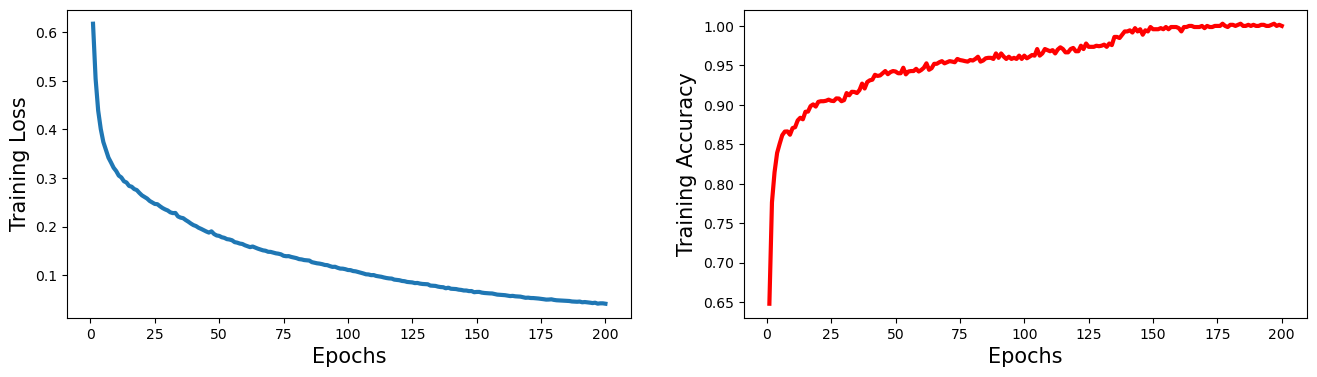

In [39]:
import matplotlib.pyplot as plt

# plot the training and validation loss learning curves + accuracies
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(np.arange(1,epochs+1), bce_loss, lw=3)
ax.set_ylabel('Training Loss', size=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(np.arange(1,epochs+1), training_acc, lw=3, color='red')
ax.set_xlabel('Epochs', size=15)
ax.set_ylabel('Training Accuracy', size=15)
plt.show()


In [41]:
# Test data using params
best_result = results.get_best_result()

model = MLP(13)

# extract checkpoint and config
best_config = best_result.config
best_checkpoint = best_result.checkpoint.as_directory()

# load saved model from the best checkpoint directory per epoch
with best_checkpoint as checkpoint_dir:
    # The model state dict was saved under `model.pth` by the training function
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, "model.pth")))

In [42]:

df = pd.read_csv(PROJECT_DIR+'/'+"heart.csv")

# split into X and y columns
idx = len(df.columns) - 1
X = df.iloc[:, :idx]
y = df.loc[:, 'target']

# get and load test data
test_ds = HeartDiseaseDataset(X,y)
X_test = test_ds.X_test
y_test = test_ds.y_test

In [43]:
accuracy = 0

pred = model(X_test)[:,0]
is_correct = ((pred >= 0.5).float() == y_test).float()
accuracy += is_correct.mean()

print(f'Test Accuracy: {accuracy.numpy(): .4f}%')

Test Accuracy:  0.9708%


In [44]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test.numpy(), (pred>= 0.5).detach().numpy())

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

print(f'Total predictions: {y_test.size(0)}')
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

Total predictions: 308
True Positives (TP): 152
True Negatives (TN): 147
False Positives (FP): 3
False Negatives (FN): 6


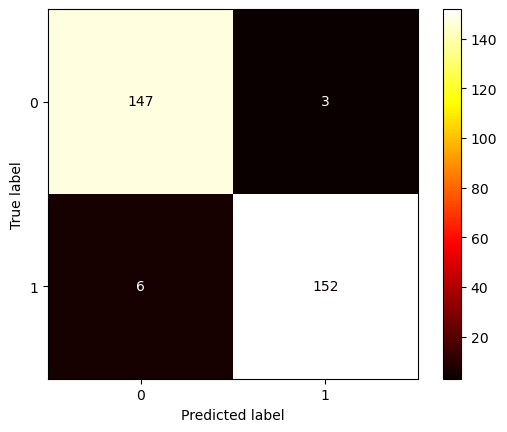

In [45]:
# confusion matrix plot
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])

disp.plot(cmap=plt.cm.hot)
plt.show()

/var/folders/2j/1q6627rd63n0qq4cxzs4fn6r0000gn/T/ipykernel_91856/2853675582.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='r')


<Figure size 1600x800 with 0 Axes>

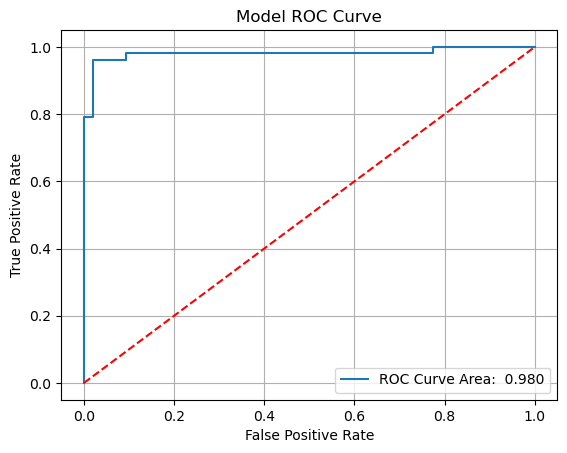

In [46]:
# precision recall curve plot
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test.numpy(), pred.detach().numpy(), pos_label=1)
roc_auc = metrics.auc(fpr, tpr)

fig = plt.figure(figsize=(16,8))
fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f'ROC Curve Area: {roc_auc: .3f}')                                                                        
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='Model ROC Curve')

plt.legend()
ax.grid()
plt.plot([0, 1], [0, 1], 'k--', color='r')
fig.savefig("test.png")
plt.show()

In [48]:
print('best_checkpoint_file_path: ', file_path)

best_checkpoint_file_path:  /Users/fatimasaadatali/heart_disease_mlp/HeartDiseaseMLP/model_params/train_08597_00000_0_beta1=0.8031,beta2=0.9890,epsilon=0.0000,lr=0.0018_2026-09-27_18-09-19/checkpoint_000039
